In [1]:
%matplotlib widget

In [1]:
import museval
from museval import iris_utils
from irispy.io import read_files
import json
from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from astropy.modeling import models as m
from astropy.modeling.fitting import LMLSQFitter, LevMarLSQFitter, TRFLSQFitter, parallel_fit_dask
from dask.distributed import Client
import matplotlib.pyplot as plt
import numpy as np
from irispy.spectrograph import SpectrogramCube
import warnings

In [173]:
obs_data_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AR_datasets/'
target_url = 'https://www.lmsal.com/hek/hcr?cmd=search-events3&outputformat=json&startTime=2020-12-27T16:00&stopTime=2020-12-27T18:00&hasData=true&hideMostLimbScans=true&obsDesc=12795&limit=200'
downloaded_filename=iris_utils.download_hek_json(target_url, obs_data_dir)

In [174]:
with open(downloaded_filename, "r") as f:
    data = json.load(f)

target_url = iris_utils.find_iris_raster_url(data, min_exptime=4)
raster_filename = iris_utils.download_iris_raster(target_url, obs_data_dir)


*** Maximum exposure time for this IRIS observation: 8 s


In [175]:
raster = read_files(raster_filename, memmap=False)
raster


Raster Collection
-----------------
Spectral Windows (cube keys): (np.str_('C II 1336'), np.str_('Si IV 1394'), np.str_('Mg II k 2796'))
Number of Cubes: 3
Aligned dimensions: [1 320 548]
Aligned physical types: [('meta.obs.sequence',), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon', 'time'), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon')]

In [13]:
raster.keys()
si_iv_1394 = raster['Si IV 1394'][0]
si_iv_1394_core = 139.375 * u.nm
lower_corner = [SpectralCoord(si_iv_1394_core), None]
upper_corner = [SpectralCoord(si_iv_1394_core), None]
si_iv_spec_crop = si_iv_1394.crop(lower_corner, upper_corner)

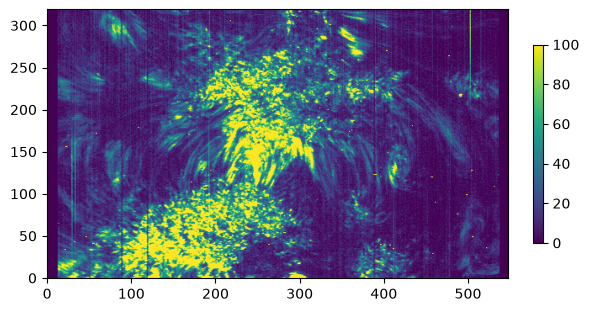

In [16]:
plt.figure()
plt.imshow(si_iv_spec_crop.data,vmin=0,vmax=100,cmap='viridis', origin='lower')
plt.colorbar(fraction=0.02)
plt.show()

In [8]:
normalized_unit = si_iv_1394.unit / u.s
exposure_time_reshaped = si_iv_1394.exposure_time.value[:, np.newaxis, np.newaxis]
normalized_data = si_iv_1394.data/ exposure_time_reshaped
normalized_data = np.where(np.isnan(normalized_data), 0, normalized_data) # can be nan because of the zero exposure time
normalized_si_iv_spec = SpectrogramCube(
                    normalized_data,
                    si_iv_1394.wcs,
                    meta=si_iv_1394.meta,
                    unit=normalized_unit,
                    uncertainty=si_iv_1394.uncertainty,
                    copy=True,
                )
wl_sum = normalized_si_iv_spec.rebin((1, 1, normalized_si_iv_spec.data.shape[-1]), operation=np.sum)[0]
spatial_mean = normalized_si_iv_spec.rebin((*normalized_si_iv_spec.data.shape[:-1], 1))[0, 0, :]
initial_model = m.Const1D(amplitude=1/si_iv_1394.exposure_time.value[0] * normalized_si_iv_spec.unit) + m.Gaussian1D(
                    amplitude=np.nanmax(spatial_mean.data) * normalized_si_iv_spec.unit, mean=si_iv_1394_core, stddev=0.005 * u.nm
                )
wavelength_coords = spatial_mean.axis_world_coords("em.wl")[0].to(u.nm)
fitter = TRFLSQFitter() #LevMarLSQFitter(): apparently it is a legacy fitter and not recommended for new code. Use LMLSQFitter() instead.
average_fit = fitter(
                    initial_model,
                    wavelength_coords,
                    # spatial_mean.axis_world_coords("em.wl")[0].to(u.nm),
                    spatial_mean.data * spatial_mean.unit,
                    filter_non_finite = True,  # Allow fitting with non-finite values
                )
filtered_data = np.where(normalized_si_iv_spec.data < 0, 0, normalized_si_iv_spec.data)
filtered_data = np.where(np.isfinite(filtered_data), filtered_data, 0)

In [9]:
filtered_data.min(), filtered_data.max()

(np.float64(0.0), np.float64(2022.9749998658747))

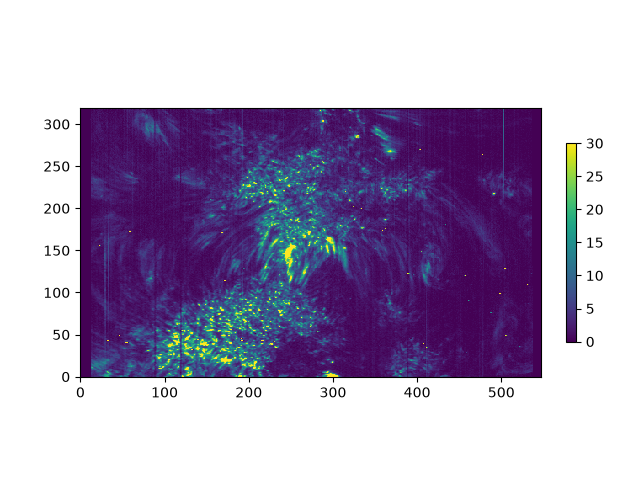

In [10]:
plt.figure()
plt.imshow(normalized_si_iv_spec.crop(lower_corner, upper_corner).data, vmin=0, vmax=30,cmap='viridis', origin='lower',
           interpolation='none')
plt.colorbar(fraction=0.02)
plt.show()

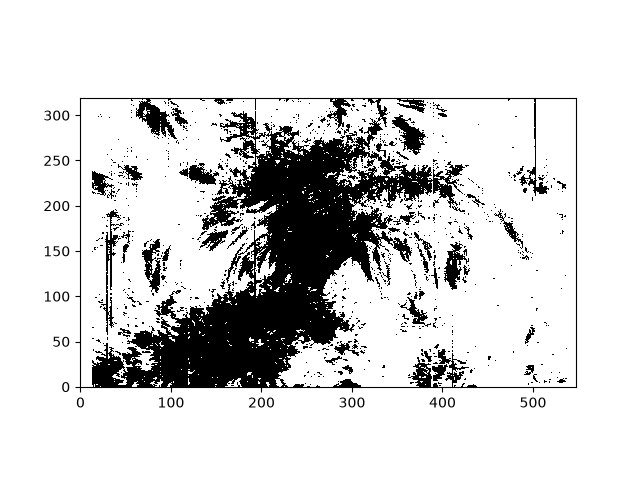

In [26]:
fit_mask = np.where(normalized_si_iv_spec.crop(lower_corner, upper_corner).data >= np.nanpercentile(normalized_si_iv_spec.crop(lower_corner, upper_corner).data.flatten(), 68), 1, np.nan)
# fit_mask1 = fit_mask[:,:,np.newaxis]
plt.figure()
plt.imshow(fit_mask, origin='lower',cmap='gray', interpolation='none')
plt.show()

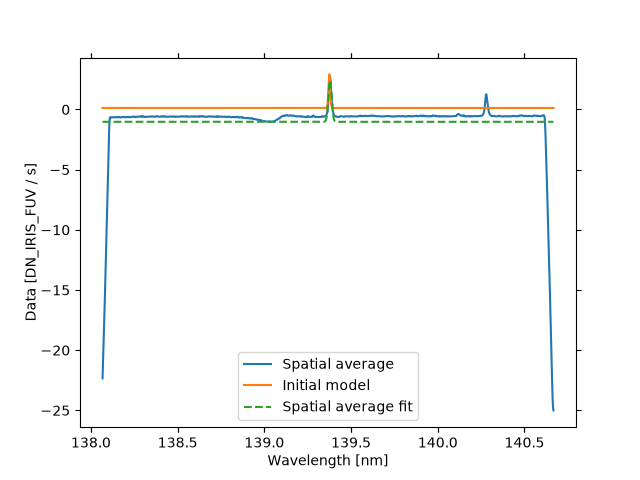

In [11]:
wavelength_coords = spatial_mean.axis_world_coords("em.wl")[0].to(u.nm)
fig = plt.figure()
ax = spatial_mean.plot(label="Spatial average")
ax.plot(initial_model(wavelength_coords), label="Initial model")
ax.plot(average_fit(wavelength_coords), linestyle="--", label="Spatial average fit")
plt.legend()
plt.show()
# ax.set_xlim([wavelength_coords[10].value, wavelength_coords[-15].value])

In [12]:
client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fitted_params = parallel_fit_dask(data=filtered_data,
                                      data_unit=normalized_si_iv_spec.unit,
                                      model=average_fit,
                                      fitting_axes=2,
                                    #   mask=fit_mask1,
                                      world= (wavelength_coords,),
                                      fitter=fitter,
                                      scheduler=client,
    )


In [17]:
import astropy.constants as constants
net_flux = (
    np.sqrt(2 * np.pi)
    * (fitted_params.amplitude_0 + fitted_params.amplitude_1)
    * fitted_params.stddev_1.quantity
    / np.mean(si_iv_1394.axis_world_coords("wl")[0][1:] - si_iv_1394.axis_world_coords("wl")[0][:-1]).to(u.nm)
)

core_shift = ((fitted_params.mean_1.quantity.to(u.nm)) - si_iv_1394_core) / si_iv_1394_core * (constants.c.to(u.km / u.s))
sigma = (fitted_params.stddev_1.quantity.to(u.nm)) / si_iv_1394_core * (constants.c.to(u.km / u.s))

NameError: name 'net_flux' is not defined

<Figure size 640x480 with 0 Axes>

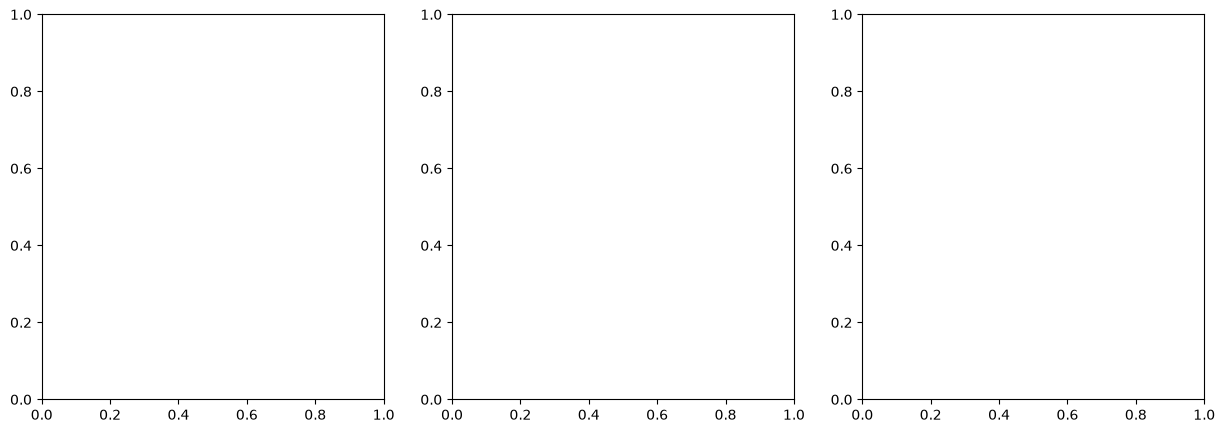

In [36]:
plt.close('all')
plt.figure()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(net_flux.data, cmap='bone_r', origin='lower', vmin=0, vmax=120, interpolation='none')
ax[0].set_title('Net Flux')
ax[1].imshow(core_shift.data*fit_mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
ax[1].set_title('Core Shift')
ax[2].imshow(sigma.data*fit_mask, cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
ax[2].set_title('Sigma')
# plt.show()

In [ ]:
if __name__ == "__main__":
    client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
    iris_model_fit, si_iv_1394 = iris_utils.fit_si_iv(raster, client)
    client.close()

In [ ]:
date_begin = raster['Si IV 1394'].meta['Date_Obs'].split('T')[0]
iris_utils.save_fit_results(iris_model_fit, si_iv_1394, date_begin, obs_data_dir)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

save_path = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AR_datasets/'
fitted_params = np.load(save_path+'iris_fit_results_1394_2020-12-27.npz', allow_pickle=True)


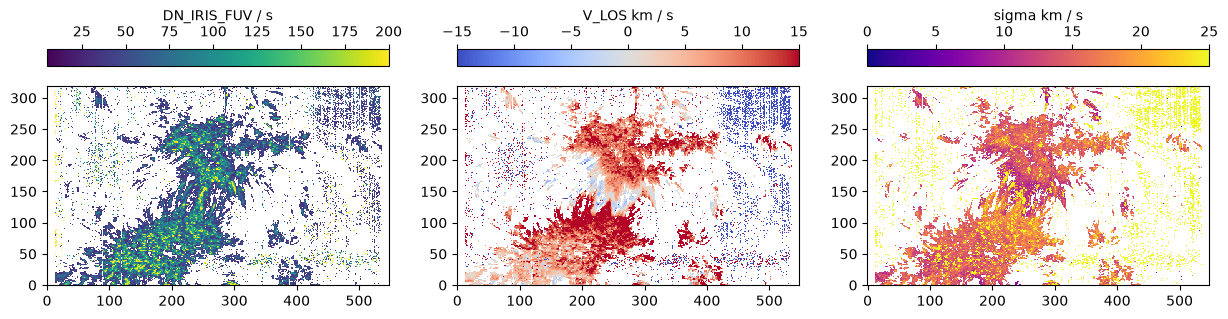

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax = ax.ravel()
im=ax[0].imshow(fitted_params['net_flux']*mask, cmap='viridis', origin='lower',vmax=200, vmin=5, interpolation='none')
plt.colorbar(im, location='top', label=fitted_params['net_flux_unit'])
im = ax[1].imshow(fitted_params['core_shift']*mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
plt.colorbar(im, location='top', label='V_LOS'+' ' +fitted_params['core_shift_unit'])
im =ax[2].imshow(fitted_params['sigma']*mask,cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
plt.colorbar(im, location='top', label='sigma '+fitted_params['sigma_unit'])


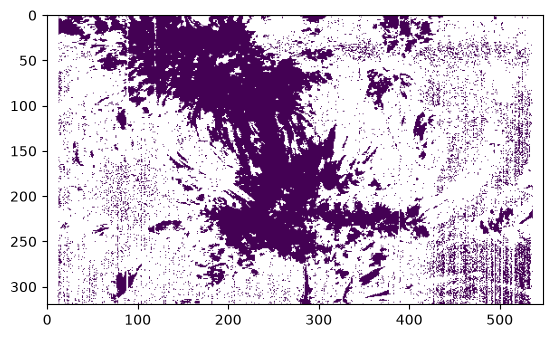

In [43]:
mask  = np.where(fitted_params['net_flux'] >= np.nanpercentile(hist_data, 68), 1, np.nan)
plt.imshow(mask)

## Radiometric Calibration

In [17]:
from irispy.utils.spectrograph import radiometric_calibration
si_iv_1394 = raster['Si IV 1394'][0]
calibrated_si_iv_1394 = radiometric_calibration(si_iv_1394)

/Users/souvikb/miniforge3/envs/muse_bose_312/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/souvikb/miniforge3/envs/muse_bose_312/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [171]:
help(calibrated_si_iv_1394)

Help on SpectrogramCube in module irispy.spectrograph object:

class SpectrogramCube(sunraster.spectrogram.SpectrogramCube)
 |  SpectrogramCube(data, wcs, uncertainty, unit, meta, *, mask=None, copy=False, **kwargs) -> None
 |
 |  Class representing spectrogram data described by a single WCS.
 |
 |  Idea is that this class holds one complete raster scan or a sit and stare.
 |
 |  Parameters
 |  ----------
 |  data: `numpy.ndarray`
 |      The array holding the actual data in this object.
 |  wcs: `astropy.wcs.WCS`
 |      The WCS object containing the axes' information
 |  unit : `astropy.units.Unit` or `str`
 |      Unit for the dataset. Strings that can be converted to a Unit are allowed.
 |  meta : `dict` object
 |      Additional meta information about the dataset. Must contain at least the
 |      following keys:
 |      - detector type: str, (FUV1, FUV2 or NUV)
 |      - OBSID: int
 |      - spectral window: str
 |  uncertainty : any type, optional
 |      Uncertainty in the data

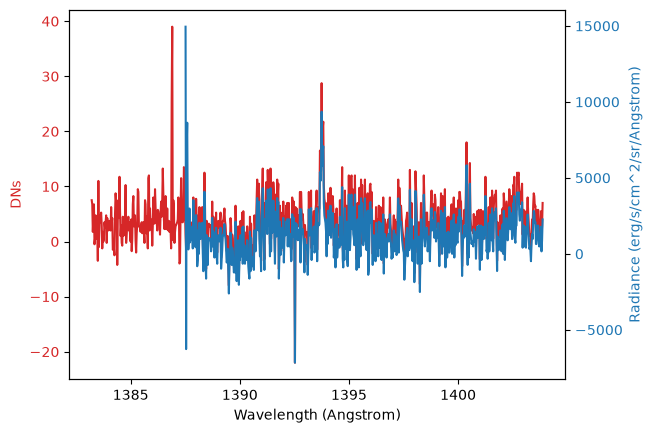

In [12]:
fig, ax = plt.subplots()
color = 'tab:red'
ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel('DNs', color=color)
ax.plot(si_iv_1394.spectral_axis[100:-110].to('angstrom'), si_iv_1394.data[150, 200, 100:-110], 
        label='Original',
        color=color)
ax.tick_params(axis="y", labelcolor=color)

ax2 = ax.twinx()

color = 'tab:blue'
ax2.set_ylabel('Radiance (erg/s/cm^2/sr/Angstrom)', color=color)
ax2.plot(calibrated_si_iv_1394.spectral_axis[100:-110].to('angstrom'), calibrated_si_iv_1394.data[150, 200, 100:-110], 
         label='Calibrated',
         color=color)
ax2.tick_params(axis="y", labelcolor=color) 


In [19]:
calibrated_si_iv_1394.unit, si_iv_1394_core

(Unit("erg / (Angstrom s sr cm2)"), <Quantity 139.375 nm>)

In [78]:
wl_sum = calibrated_si_iv_1394.rebin((1, 1, calibrated_si_iv_1394.data.shape[-1]), operation=np.sum)[0]
spatial_mean = calibrated_si_iv_1394.rebin((*calibrated_si_iv_1394.data.shape[:-1], 1))[0, 0, :]
wavelength_axis = calibrated_si_iv_1394.axis_world_coords("em.wl")[0].to(u.nm)
core_window = np.abs(wavelength_axis - si_iv_1394_core) < 0.15 * u.nm  # adjust half-width to line width
initial_model = m.Const1D(amplitude=1/calibrated_si_iv_1394.exposure_time.value[0] * calibrated_si_iv_1394.unit) + m.Gaussian1D(
                    amplitude=np.nanmax(spatial_mean.data[core_window]) * calibrated_si_iv_1394.unit, mean=si_iv_1394_core, stddev=0.005 * u.nm
                )

fitter = TRFLSQFitter() #LevMarLSQFitter(): apparently it is a legacy fitter and not recommended for new code. Use LMLSQFitter() instead.
average_fit = fitter(
                    initial_model,
                    wavelength_axis,
                    # spatial_mean.axis_world_coords("em.wl")[0].to(u.nm),
                    spatial_mean.data * spatial_mean.unit,
                    filter_non_finite = True,  # Allow fitting with non-finite values
                )
filtered_data = np.where(calibrated_si_iv_1394.data < 0, 0, calibrated_si_iv_1394.data)
filtered_data = np.where(np.isfinite(filtered_data), filtered_data, 0)

/Users/souvikb/miniforge3/envs/muse_bose_312/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


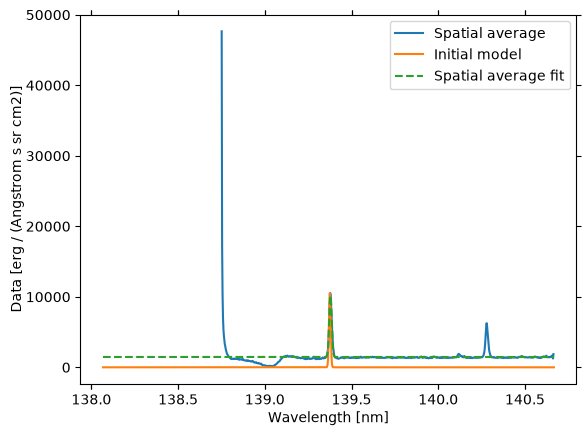

In [79]:
fig = plt.figure()
ax = spatial_mean.plot(label="Spatial average")
ax.plot(initial_model(wavelength_axis), label="Initial model")
ax.plot(average_fit(wavelength_axis), linestyle="--", label="Spatial average fit")
plt.legend()

In [80]:

client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fitted_params = parallel_fit_dask(data=filtered_data,
                                      data_unit=calibrated_si_iv_1394.unit,
                                      model=average_fit,
                                      fitting_axes=2,
                                    #   mask=fit_mask1,
                                      world= (wavelength_axis,),
                                      fitter=fitter,
                                      scheduler=client,
    )
client.close()


2026-08-18 18:35:22,916 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:63373' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('data', 7, 13, 0), ('data', 7, 24, 0), ('data', 6, 0, 0), ('data', 5, 18, 0), ('data', 2, 23, 0), ('data', 6, 13, 0), ('data', 9, 11, 0), ('data', 13, 12, 0), ('data', 9, 2, 0), ('data', 3, 2, 0), ('data', 3, 13, 0), ('data', 13, 16, 0), ('data', 5, 20, 0), ('data', 7, 19, 0), ('data', 5, 13, 0), ('data', 2, 18, 0), ('data', 6, 19, 0), ('data', 14, 9, 0), ('data', 7, 8, 0), ('data', 4, 24, 0), ('data', 4, 13, 0), ('data', 5, 24, 0), ('data', 10, 18, 0), ('data', 8, 23, 0), ('data', 14, 0, 0), ('data', 6, 3, 0), ('data', 4, 8, 0), ('data', 4, 19, 0), ('data', 13, 24, 0), ('data', 12, 9, 0), ('data', 8, 12, 0), ('data', 14, 24, 0), ('data', 8, 3, 0), ('data', 14, 15, 0), ('data', 8, 18, 0), ('data', 2, 8, 0), ('data', 14, 19, 0), ('data', 6, 9, 0), ('data', 3, 3, 0), ('data', 9, 18, 0), ('data', 2, 1

In [140]:
import astropy.constants as constants
si_iv_core = 139.375 * u.nm
net_flux = (
    np.sqrt(2 * np.pi)
    * (fitted_params.amplitude_0 + fitted_params.amplitude_1)
    * fitted_params.stddev_1.quantity
)

core_shift = ((fitted_params.mean_1.quantity.to(u.nm)) - si_iv_core) / si_iv_core * (constants.c.to(u.km / u.s))
sigma = (fitted_params.stddev_1.quantity.to(u.nm)) / si_iv_core * (constants.c.to(u.km / u.s))

In [92]:
np.mean(wavelength_axis[1:] - wavelength_axis[:-1]).to(u.nm),fitted_params.amplitude_0 + fitted_params.amplitude_1

(<Quantity 0.002544 nm>,
 <Quantity [[6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23],
            [6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23],
            [6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23],
            ...,
            [6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23],
            [6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23],
            [6.36929072e-23, 6.36929072e-23, 6.36929072e-23, ...,
             6.36929072e-23, 6.36929072e-23, 6.36929072e-23]] erg / (Angstrom s sr cm2)>)

/var/folders/nk/5w7wz2p12dj2qhgqnyrvk0hh0000gp/T/ipykernel_80106/1271791507.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(si_iv_spec_crop.data),cmap='viridis', origin='lower')
/var/folders/nk/5w7wz2p12dj2qhgqnyrvk0hh0000gp/T/ipykernel_80106/1271791507.py:7: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(si_iv_spec_crop.data),cmap='viridis', origin='lower')


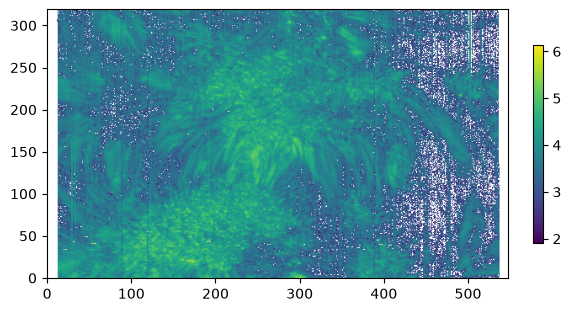

In [43]:
raster.keys()
si_iv_1394 = raster['Si IV 1394'][0]
si_iv_1394_core = 139.375 * u.nm
lower_corner = [SpectralCoord(si_iv_1394_core), None]
upper_corner = [SpectralCoord(si_iv_1394_core), None]
si_iv_spec_crop = calibrated_si_iv_1394.crop(lower_corner, upper_corner)
plt.imshow(np.log10(si_iv_spec_crop.data),cmap='viridis', origin='lower')
plt.colorbar(fraction=0.02)

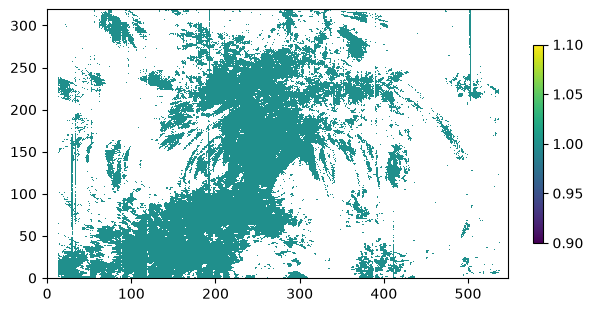

In [165]:
fit_mask = np.where(calibrated_si_iv_1394.crop(lower_corner, upper_corner).data >= np.nanpercentile(calibrated_si_iv_1394.crop(lower_corner, upper_corner).data.flatten(), 68), 1, np.nan)
# fit_mask1 = fit_mask[:,:,np.newaxis]
plt.figure()
plt.imshow(fit_mask, origin='lower',cmap='viridis', interpolation='none')
plt.colorbar(fraction=0.02)
plt.show()

Text(0.5, 1.0, 'Sigma')

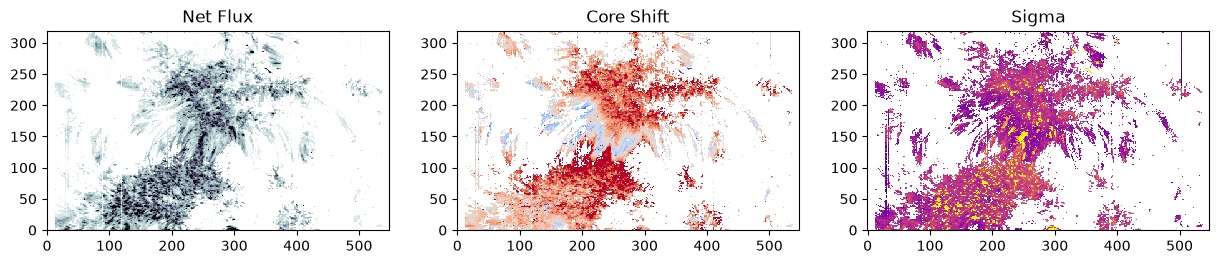

In [109]:
# plt.close('all')
# plt.figure()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(net_flux.data*fit_mask, cmap='bone_r', origin='lower', interpolation='none',vmin=0, vmax=5e5)
ax[0].set_title('Net Flux')
ax[1].imshow(core_shift.data*fit_mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
ax[1].set_title('Core Shift')
ax[2].imshow(sigma.data*fit_mask, cmap='plasma', origin='lower',vmin=0, vmax=35, interpolation='none')
ax[2].set_title('Sigma')
# plt.show()

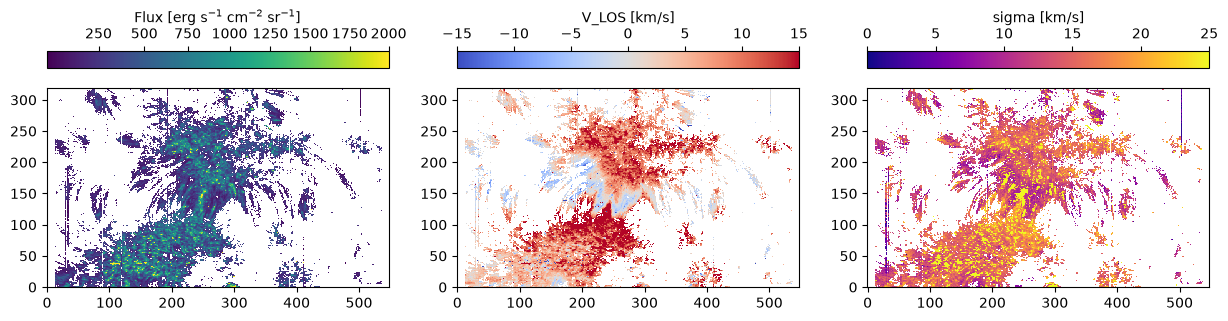

In [169]:
from matplotlib import colors
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax = ax.ravel()
im=ax[0].imshow(net_flux.data*fit_mask, cmap='viridis', origin='lower',norm=colors.PowerNorm(0.9,vmax=2e3, vmin=5), interpolation='none')
plt.colorbar(im, location='top', label=r'Flux [erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$]')
im = ax[1].imshow(core_shift.data*fit_mask, cmap='coolwarm', origin='lower',vmax=15, vmin=-15, interpolation='none')
plt.colorbar(im, location='top', label='V_LOS [km/s]')
im =ax[2].imshow(sigma.data*fit_mask,cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
plt.colorbar(im, location='top', label='sigma [km/s]')


In [167]:
save_path = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AR_datasets/'

In [ ]:
.savez(save_path+'rad_cal_iris_fit_results_1394_2020-12-27.npz', flux =net_flux.data, core_shift = core_shift.data, sigma = sigma.data,
         mask = fit_mask)np

## QS dataset

In [5]:
from irispy.utils.spectrograph import radiometric_calibration
filename = '933f359152248bd35ab7ad75736e940f-iris_l2_20140607_120934_3820611296_raster.tar.gz'
QS_path = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/IRIS_only/IRIS_datasets/2014-06-07T12:09:00/'


In [6]:
raster_QS = read_files(QS_path+filename, memmap=False)
raster_QS


Raster Collection
-----------------
Spectral Windows (cube keys): (np.str_('C II 1336'), np.str_('Fe XII 1349'), np.str_('O I 1356'), np.str_('Si IV 1394'), np.str_('Si IV 1403'), np.str_('2832'), np.str_('2814'), np.str_('Mg II k 2796'))
Number of Cubes: 8
Aligned dimensions: [2 400 548]
Aligned physical types: [('meta.obs.sequence',), ('custom:pos.helioprojective.lat', 'time', 'custom:pos.helioprojective.lon'), ('custom:pos.helioprojective.lat', 'custom:pos.helioprojective.lon')]

In [14]:
si_iv_1394 = raster_QS['Si IV 1394'][0]
calibrated_si_iv_1394 = radiometric_calibration(si_iv_1394)
si_iv_1394_core = 139.375 * u.nm
lower_corner = [SpectralCoord(si_iv_1394_core), None]
upper_corner = [SpectralCoord(si_iv_1394_core), None]

In [10]:
wl_sum = calibrated_si_iv_1394.rebin((1, 1, calibrated_si_iv_1394.data.shape[-1]), operation=np.sum)[0]
spatial_mean = calibrated_si_iv_1394.rebin((*calibrated_si_iv_1394.data.shape[:-1], 1))[0, 0, :]
wavelength_axis = calibrated_si_iv_1394.axis_world_coords("em.wl")[0].to(u.nm)
core_window = np.abs(wavelength_axis - si_iv_1394_core) < 0.15 * u.nm  # adjust half-width to line width
initial_model = m.Const1D(amplitude=1/calibrated_si_iv_1394.exposure_time.value[0] * calibrated_si_iv_1394.unit) + m.Gaussian1D(
                    amplitude=np.nanmax(spatial_mean.data[core_window]) * calibrated_si_iv_1394.unit, mean=si_iv_1394_core, stddev=0.005 * u.nm
                )

fitter = TRFLSQFitter() #LevMarLSQFitter(): apparently it is a legacy fitter and not recommended for new code. Use LMLSQFitter() instead.
average_fit = fitter(
                    initial_model,
                    wavelength_axis,
                    # spatial_mean.axis_world_coords("em.wl")[0].to(u.nm),
                    spatial_mean.data * spatial_mean.unit,
                    filter_non_finite = True,  # Allow fitting with non-finite values
                )
filtered_data = np.where(calibrated_si_iv_1394.data < 0, 0, calibrated_si_iv_1394.data)
filtered_data = np.where(np.isfinite(filtered_data), filtered_data, 0)

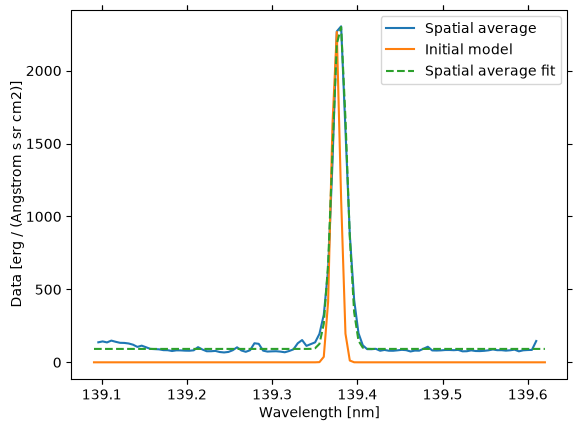

In [11]:
fig = plt.figure()
ax = spatial_mean.plot(label="Spatial average")
ax.plot(initial_model(wavelength_axis), label="Initial model")
ax.plot(average_fit(wavelength_axis), linestyle="--", label="Spatial average fit")
plt.legend()

In [12]:
client = Client(n_workers=10, threads_per_worker=1, memory_limit="8GB", dashboard_address=None)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fitted_params = parallel_fit_dask(data=filtered_data,
                                      data_unit=calibrated_si_iv_1394.unit,
                                      model=average_fit,
                                      fitting_axes=2,
                                    #   mask=fit_mask1,
                                      world= (wavelength_axis,),
                                      fitter=fitter,
                                      scheduler=client,
    )
client.close()


In [26]:
import astropy.constants as constants
si_iv_core = 139.375 * u.nm
net_flux = (
    np.sqrt(2 * np.pi)
    * (fitted_params.amplitude_0 + fitted_params.amplitude_1)
    * fitted_params.stddev_1.quantity
)

core_shift = ((fitted_params.mean_1.quantity.to(u.nm)) - si_iv_core) / si_iv_core * (constants.c.to(u.km / u.s))
sigma = (fitted_params.stddev_1.quantity.to(u.nm)) / si_iv_core * (constants.c.to(u.km / u.s))

Text(0.5, 0.98, 'Si IV 1394: 20140607_120934_3820611296')

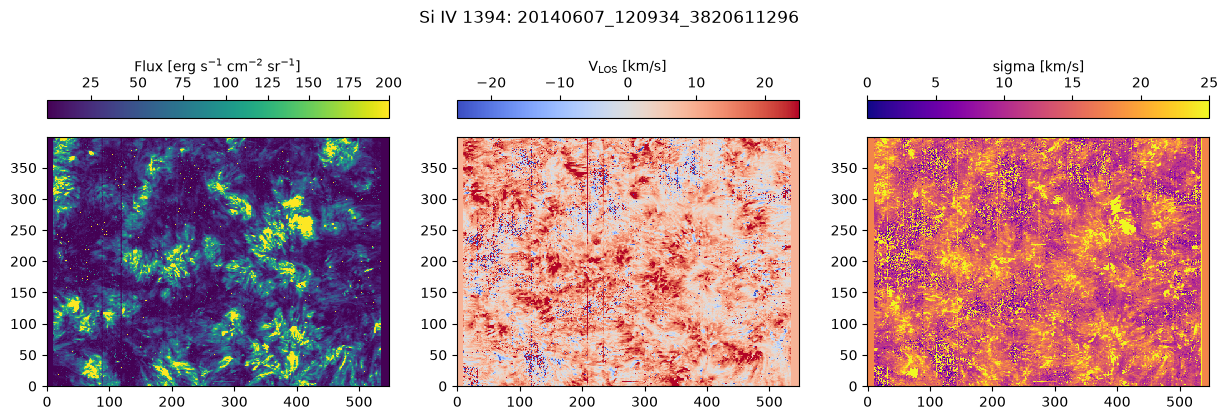

In [25]:
from matplotlib import colors
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax = ax.ravel()
im=ax[0].imshow(net_flux.data, cmap='viridis', origin='lower',norm=colors.PowerNorm(0.9,vmax=0.2e3, vmin=5), interpolation='none')
plt.colorbar(im, location='top', label=r'Flux [erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$]')
im = ax[1].imshow(core_shift.data, cmap='coolwarm', origin='lower',vmax=25, vmin=-25, interpolation='none')
plt.colorbar(im, location='top', label=r'V$_{\mathrm{LOS}}$ [km/s]')
im =ax[2].imshow(sigma.data,cmap='plasma', origin='lower',vmin=0, vmax=25, interpolation='none')
plt.colorbar(im, location='top', label='sigma [km/s]')
plt.suptitle('Si IV 1394: 20140607_120934_3820611296')


In [27]:
np.savez(QS_path+'rad_cal_iris_fit_results_2014-06-07T12-09-00.npz',flux =net_flux.data, core_shift = core_shift.data, sigma = sigma.data)